# Multi-Parameter Confidence Contours with Spey

This notebook demonstrates how to map **multi-dimensional chi-squared confidence contours** using the `spey.multiparameter` sub-package.  We work with a two-bin counting experiment whose signal is a linear combination of three benchmark signal shapes, controlled by three free parameters.  The goal is to identify the full set of **signal-shape parameter** combinations that are compatible with the observed data at the **95% confidence level**.

The **signal strength** $\mu$ is held fixed at **1** throughout.  The contour lives in the 3-dimensional space of signal-shape parameters $(c_0, c_1, c_2)$.

---

## Contents

1. [Theoretical Background](#theory)
2. [Experimental Setup](#setup)
3. [Building the Statistical Model](#model)
4. [Exploring the Likelihood Landscape](#landscape)
5. [Running `find_contour`](#contour)
6. [Visualising the Confidence Contour](#viz)
7. [Algorithm Walk-through](#algo)


(theory)=
## 1 · Theoretical Background

### The Statistical Model

We use the multivariate Gaussian likelihood for correlated bins:

$$
\mathcal{L}(\mu,\,c_0,c_1,c_2)
= \mathcal{N}\!\bigl(n\,\big|\,\mu\,s(c_0,c_1,c_2)+b,\;\Sigma\bigr),
$$

where $n$ is the observed data, $b$ the background yields, $\Sigma$ the covariance matrix, and $\mu$ the overall signal strength.  In this analysis we fix $\mu = 1$ and let the **signal-shape parameters** $(c_0, c_1, c_2)$ vary freely.

### Wilks' Theorem and the Confidence Contour

Let $\theta_s = (c_0, c_1, c_2)$ be the signal-shape parameter vector and $\hat\theta_s$ its maximum-likelihood estimate (with $\mu=1$ fixed).  Under Wilks' theorem the test statistic

$$
\chi^2(\theta_s)
= 2\bigl[\mathrm{NLL}(\theta_s) - \mathrm{NLL}(\hat\theta_s)\bigr]
$$

follows a $\chi^2_k$ distribution with $k=3$ degrees of freedom (one per free parameter).  The **95% confidence region** is

$$
\mathcal{C}_{0.95}
= \bigl\{\theta_s : \chi^2(\theta_s) \le \Delta_{0.95}\bigr\},
\qquad
\Delta_{0.95} = F^{-1}_{\chi^2_3}(0.95) \approx 7.81.
$$

The boundary — the **confidence contour** — is the 2-dimensional surface satisfying

$$
\mathrm{NLL}(\theta_s) = T,
\qquad
T = \mathrm{NLL}(\hat\theta_s) + \tfrac{\Delta_{0.95}}{2}.
$$

> **Why fix $\mu=1$?**  In many HEP analyses the signal-shape parameters $(c_0,c_1,c_2)$ encode physical model parameters (e.g. couplings, masses) while $\mu$ is a nuisance-like overall normalisation.  Fixing $\mu=1$ and profiling the shape parameters gives the confidence region in the physical parameter space of interest.


(setup)=
## 2 · Experimental Setup

We have a two-bin experiment.  The physical signal is a linear combination of three benchmark templates:

$$
s(c_0, c_1, c_2) = c_0\,s_1 + c_1^2\,s_2 + c_2\,s_3,
$$

where $c_1$ enters **quadratically** — typical when the parameter corresponds to a coupling that appears in the amplitude squared.  The total expected yield in each bin is

$$
\lambda = \mu\,s(c_0,c_1,c_2) + b = s(c_0,c_1,c_2) + b
\quad (\mu = 1).
$$

The three free parameters $(c_0, c_1, c_2)$ define a **3-dimensional** signal-parameter space.  `find_contour` maps the 2-dimensional boundary of the 95% CL region in this space.


In [ ]:
import warnings

warnings.filterwarnings("ignore")  # suppress minor optimiser warnings for clarity

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import chi2 as chi2_dist

import spey
from spey.backends.default_pdf.simple_pdf import MultivariateNormal
from spey.multiparameter import find_contour

print(f"Spey version : {spey.__version__}")
print(f"NumPy version: {np.__version__}")

Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.
Spey version : 0.2.7-b2
NumPy version: 1.24.4


In [ ]:
# ── Observed data ────────────────────────────────────────────────────────────
data = np.array([36, 33])

# ── Background yields and covariance ─────────────────────────────────────────
background_yields = np.array([50.0, 48.0])
covariance_matrix = np.array(
    [[144.0, 13.0], [25.0, 256.0]]  # σ²_0,  Cov(0,1)
)  # Cov(1,0), σ²_1

sigma_b = np.sqrt(np.diag(covariance_matrix))
print(f"Background yields   : {background_yields}")
print(f"Background σ (diag) : {sigma_b}")
print(f"Observed data       : {data}")
print(f"Deficit (data - bkg): {data - background_yields}  (negative → data below bkg)")
print(f"Total Pull (data - bkg) / σ: {sum((data - background_yields)/sigma_b):.3f}")

Background yields   : [50. 48.]
Background σ (diag) : [12. 16.]
Observed data       : [36 33]
Deficit (data - bkg): [-14. -15.]  (negative → data below bkg)
Total Pull (data - bkg) / σ: -2.104


In [ ]:
# ── Signal templates ─────────────────────────────────────────────────────────
signal_yields1 = np.array([12.0, 15.0])  # process A
signal_yields2 = np.array([6.0, 16.0])  # process B
signal_yields3 = np.array([20.0, 10.0])  # process C

# ── Parametric signal as a function of shape parameters ──────────────────────
#
#   param = (c0, c1, c2)
#
#   The backend calls  signal_yields(pars[1:])  at every evaluation,
#   where pars = [mu, c0, c1, c2] is the full 4-dim parameter vector.
#   We fix mu=1, so the effective expected yield is s(c0,c1,c2) + bkg.
#
def signal_yields(param: np.ndarray) -> np.ndarray:
    """Combined signal as a function of shape parameters (c0, c1, c2).

    c1 enters quadratically: reflects a squared-coupling dependence
    typical in EFT or BSM amplitude-squared contributions.
    """
    return (
        param[0] * signal_yields1
        + param[1] ** 2 * signal_yields2
        + param[2] * signal_yields3
    )


print("Signal at (c0, c1, c2) = (1, 1, 1) :", signal_yields(np.ones(3)))
print("Signal at (c0, c1, c2) = (0, 0, 0) :", signal_yields(np.zeros(3)))

Signal at (c0, c1, c2) = (1, 1, 1) : [38. 41.]
Signal at (c0, c1, c2) = (0, 0, 0) : [0. 0.]


(model)=
## 3 · Building the Statistical Model

We construct a `StatisticalModel` using the `MultivariateNormal` backend with `n_signal_parameters=3`.  This tells the backend that the callable `signal_yields` takes **three** extra parameters beyond $\mu$.  Internally the backend extends the optimiser parameter vector to

$$
\text{pars} = [\underbrace{\mu}_{\text{index 0 (poi\_index)}},\;
               \underbrace{c_0,\; c_1,\; c_2}_{\text{indices 1–3}}].
$$

The model knows that index 0 is the POI ($\mu$) via `cfg.poi_index = 0`.  `find_contour` uses `cfg.poi_index` to:

1. **Exclude** $\mu$ from the contour search space.
2. **Fix** $\mu=1$ when evaluating the NLL, by passing `fixed_poi_value=1.0` to the internal `fit()` call.
3. **Extract** the signal-parameter block of the Hessian for the whitening transform.

The resulting contour lives in the 3-dimensional space $(c_0, c_1, c_2)$.


In [ ]:
# ── Construct the backend ─────────────────────────────────────────────────────
backend = MultivariateNormal(
    signal_yields=signal_yields,  # callable: (c0, c1, c2) → array[2]
    background_yields=background_yields,
    data=data,
    covariance_matrix=covariance_matrix,
    n_signal_parameters=3,  # declares c0, c1, c2 as free parameters
)

stat_model = spey.StatisticalModel(backend=backend, analysis="multi_param_demo")
print(stat_model)

StatisticalModel(analysis='multi_param_demo', backend=default.multivariate_normal, calculators=['toy', 'asymptotic', 'chi_square'])


In [5]:
# ── Inspect the model configuration ──────────────────────────────────────────
cfg = stat_model.backend.config()
print(f"Total parameters    : {cfg.npar}              (mu + c0 + c1 + c2)")
print(f"All parameter names : {cfg.parameter_names}")
print(f"POI index (mu)      : {cfg.poi_index}")
print()
print("find_contour will fix mu=1 and search for the contour in the")
print(f"  {cfg.npar - 1}-dimensional subspace: {cfg.parameter_names[1:]}")

Total parameters    : 4              (mu + c0 + c1 + c2)
All parameter names : ['mu', 'signal_par_0', 'signal_par_1', 'signal_par_2']
POI index (mu)      : 0

find_contour will fix mu=1 and search for the contour in the
  3-dimensional subspace: ['signal_par_0', 'signal_par_1', 'signal_par_2']


(landscape)=
## 4 · Exploring the Likelihood Landscape

Before running the full contour finder it is instructive to:

1. Locate the **MLE of the signal parameters** $\hat\theta_s$ with $\mu=1$ fixed.
2. Compute the **NLL threshold** $T = \mathrm{NLL}(\hat\theta_s) + \Delta_{0.95}^{(k=3)}/2$.
3. Visualise 1-D NLL profiles along each signal-parameter axis.

The MLE is found by calling `maximize_likelihood` with `fixed_poi_value=1.0` (fixes $\mu=1$ in the optimizer) and `poi_indices=[1, 2, 3]` (returns $(c_0, c_1, c_2)$ values).


In [ ]:
# ── Find the MLE of signal parameters with mu fixed at 1 ─────────────────────
#
#   fixed_poi_value=1.0  →  mu (pars[poi_index]) is pinned to 1
#   poi_indices=[1,2,3]  →  return the fitted values of c0, c1, c2
#
signal_indices = [i for i in range(cfg.npar) if i != cfg.poi_index]  # [1, 2, 3]
signal_names = [cfg.parameter_names[i] for i in signal_indices]  # ['signal_par_0', ...]
k = len(signal_indices)  # = 3

poi_dict, nll_min = stat_model.maximize_likelihood(
    poi_indices=signal_indices,
    return_nll=True,
    fixed_poi_value=1.0,  # fix mu=1; forwarded to fit() via **kwargs
)
theta_mle = np.array([poi_dict[i] for i in signal_indices])  # (c0_hat, c1_hat, c2_hat)

print("MLE of signal parameters (mu=1 fixed):")
for name, val in zip(signal_names, theta_mle):
    print(f"  {name:15s} = {val:+.4f}")
print(f"\nNLL at MLE : {nll_min:.6f}")

MLE of signal parameters (mu=1 fixed):
  signal_par_0    = -1.0792
  signal_par_1    = +0.3634
  signal_par_2    = -0.0921

NLL at MLE : 7.090945


In [ ]:
# ── Chi-squared threshold ─────────────────────────────────────────────────────
#
#   DoF = k = 3 (signal-shape parameters only; mu is NOT profiled)
#
delta = chi2_dist.ppf(0.95, df=k)  # Δ_{0.95}^{(k=3)}
threshold = nll_min + delta / 2.0  # NLL threshold T

print(f"Degrees of freedom   : k = {k}  (signal-shape parameters only)")
print(f"Chi-squared quantile : Δ = {delta:.4f}  (at 95% CL, k=3)")
print(f"NLL threshold        : T = {threshold:.6f}")
print()
print("Points θs with  2[NLL(θs) − NLL(θ̂s)] ≤ Δ  lie inside the 95% CR.")

Degrees of freedom   : k = 3  (signal-shape parameters only)
Chi-squared quantile : Δ = 7.8147  (at 95% CL, k=3)
NLL threshold        : T = 10.998309

Points θs with  2[NLL(θs) − NLL(θ̂s)] ≤ Δ  lie inside the 95% CR.


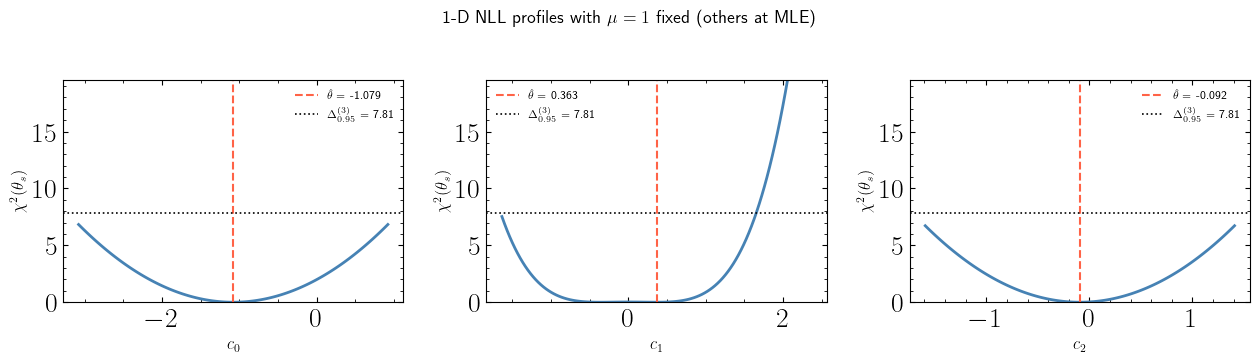

In [ ]:
# ── 1-D NLL profiles along each signal-parameter axis ────────────────────────
#
#   We build a reduced NLL function with mu=1 fixed:
#     nll_fixed(signal_pars) = -logpdf([1, signal_pars[0], signal_pars[1], signal_pars[2]])
#
logpdf_fn = stat_model.backend.get_logpdf_func()


def nll_fixed(signal_pars):
    """NLL with mu=1 fixed; takes only the 3 signal-shape parameters."""
    full_pars = np.concatenate([[1.0], signal_pars])  # [mu=1, c0, c1, c2]
    return -float(logpdf_fn(full_pars))


scan_widths = [2.0, 2.0, 1.5]
latex_names = [r"$c_0$", r"$c_1$", r"$c_2$"]

fig, axes = plt.subplots(1, k, figsize=(13, 3.8))
fig.suptitle(r"1-D NLL profiles with $\mu=1$ fixed (others at MLE)", fontsize=13)

for i, (ax, name, width) in enumerate(zip(axes, latex_names, scan_widths)):
    grid = np.linspace(theta_mle[i] - width, theta_mle[i] + width, 120)
    pars_scan = np.tile(theta_mle, (len(grid), 1))
    pars_scan[:, i] = grid
    chi2_vals = 2.0 * (np.array([nll_fixed(p) for p in pars_scan]) - nll_min)

    ax.plot(grid, chi2_vals, color="steelblue", lw=2)
    ax.axvline(
        theta_mle[i],
        color="tomato",
        ls="--",
        lw=1.5,
        label=rf"$\hat{{\theta}}$ = {theta_mle[i]:.3f}",
    )
    ax.axhline(
        delta,
        color="k",
        ls=":",
        lw=1.2,
        label=rf"$\Delta_{{0.95}}^{{(3)}}$ = {delta:.2f}",
    )
    ax.set_xlabel(name, fontsize=12)
    ax.set_ylabel(r"$\chi^2(\theta_s)$", fontsize=12)
    ax.legend(fontsize=8)
    ax.set_ylim(0, delta * 2.5)

plt.tight_layout()
plt.show()

The horizontal dotted line marks $\Delta_{0.95}^{(k=3)} \approx 7.81$.  Each 1-D profile intersection gives a marginal 95% CI for that parameter — but the full multi-dimensional shape can have non-trivial correlations, motivating the 2-D surface mapping.


(contour)=
## 5 · Running `find_contour`

`find_contour` detects `cfg.poi_index` automatically and:

- **Fixes** $\mu=1$ when evaluating the NLL by passing `fixed_poi_value=1.0` to the optimizer.
- **Builds a reduced NLL** $\mathrm{NLL}(c_0,c_1,c_2)$ using `autograd.numpy.concatenate` to insert $\mu=1$ at the correct position — keeping the function fully differentiable for the RATTLE stage.
- **Uses the $3\times 3$ signal-parameter block** of the full $4\times 4$ Hessian for the whitening transform.
- **Returns** contour points in the 3-D signal-parameter space with DoF = 3 and $\Delta_{0.95} \approx 7.81$.

| Stage | What it does |
|---|---|
| **Pre-whitening** | Fisher-information Cholesky in signal space → approximately spherical contour |
| **Radial search** | $N$ random rays + Brent root-finding along each |
| **Gap detection** | Cosine-similarity coverage scoring → seed directions |
| **RATTLE HMC** | Constrained Hamiltonian chain walking along $\mathrm{NLL}=T$ |


In [ ]:
# ── Run the contour finder ────────────────────────────────────────────────────
#
#   find_contour automatically uses cfg.poi_index to exclude mu and
#   fix it at 1.  No manual handling of mu is needed.
#
result = find_contour(
    stat_model,
    confidence_level=0.95,
    n_radial=2000,  # Stage 2: random radial rays
    n_hmc_chains=100,  # Stage 4: RATTLE chains (gap seeds)
    n_hmc_steps=4000,  # Stage 4: leapfrog steps per chain
    hmc_step_size=0.05,  # Stage 4: leapfrog step size ε
    n_gap_candidates=3000,  # Stage 3: candidate directions for gap detection
    random_seed=42,
    bounds=[(-50, 1), (None, None), (None, None)],
    n_jobs=8,
)
print(result)

Running HMC Chain: 8it [00:00, 25.86it/s]

Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.
Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.


Running HMC Chain: 16it [00:04,  3.43it/s]

Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.
Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.
Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.
Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.
Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.
Spey - WARNING: An unstable version of Spey (0.2.7-b2) is being used. Latest stable version is 0.2.6.


Running HMC Chain: 100it [00:33,  3.02it/s]


ContourResult(theta_mle=array([-1.07916624,  0.36336828, -0.09214556]), nll_min=7.090944826540303, threshold=10.998308778165892, delta=7.8147279032511765, contour_points=array([[ -2.84559878,   1.9755481 ,   0.64245939],
       [  0.55722097,  -1.24603069,  -0.69750495],
       [  0.24860554,  -1.24318741,  -0.38716747],
       ...,
       [-49.9221291 ,  -5.51807397,  20.26939748],
       [-49.95411055,  -5.51889602,  20.32220829],
       [-49.98602794,  -5.51984623,  20.37516206]]), from_radial=array([ True,  True,  True, ..., False, False, False]), parameter_names=['signal_par_0', 'signal_par_1', 'signal_par_2'], confidence_level=0.95, dof=3)


In [11]:
# ── Inspect the ContourResult ─────────────────────────────────────────────────
print("=" * 55)
print("ContourResult summary")
print("=" * 55)
print(f"Confidence level      : {result.confidence_level:.0%}")
print(f"Degrees of freedom    : k = {result.dof}  (signal-shape params only)")
print(f"Chi-squared threshold : Δ = {result.delta:.4f}")
print(f"NLL at MLE (mu=1)     : {result.nll_min:.6f}")
print(f"NLL threshold         : T = {result.threshold:.6f}")
print()
print("Signal-parameter MLE (mu=1 fixed):")
for name, val in zip(result.parameter_names, result.theta_mle):
    print(f"  {name:18s} = {val:+.4f}")
print()
print(f"Total contour points  : {len(result.contour_points)}")
print(f"  From radial search  : {result.from_radial.sum()}")
print(f"  From RATTLE HMC     : {(~result.from_radial).sum()}")

ContourResult summary
Confidence level      : 95%
Degrees of freedom    : k = 3  (signal-shape params only)
Chi-squared threshold : Δ = 7.8147
NLL at MLE (mu=1)     : 7.090945
NLL threshold         : T = 10.998309

Signal-parameter MLE (mu=1 fixed):
  signal_par_0       = -1.0792
  signal_par_1       = +0.3634
  signal_par_2       = -0.0921

Total contour points  : 149249
  From radial search  : 1959
  From RATTLE HMC     : 147290


In [ ]:
# ── Verify that contour points satisfy NLL(θs) ≈ T ───────────────────────────
rng_check = np.random.default_rng(0)
check_idx = rng_check.choice(
    len(result.contour_points),
    size=min(40, len(result.contour_points)),
    replace=False,
)

residuals = np.array(
    [nll_fixed(result.contour_points[i]) - result.threshold for i in check_idx]
)

print(f"Spot-check of {len(check_idx)} contour points:")
print(f"  Max  |NLL(θs) − T| = {np.abs(residuals).max():.2e}")
print(f"  Mean |NLL(θs) − T| = {np.abs(residuals).mean():.2e}")
print()
print("All residuals small → points lie on the constraint surface.")

Spot-check of 40 contour points:
  Max  |NLL(θs) − T| = 3.83e-10
  Mean |NLL(θs) − T| = 4.35e-11

All residuals small → points lie on the constraint surface.


(viz)=
## 6 · Visualising the Confidence Contour

With $k=3$ signal-shape parameters the confidence contour is a **2-dimensional surface** in 3-dimensional space.  We show:

- Three **pairwise 2-D projections**: $(c_0,c_1)$, $(c_0,c_2)$, $(c_1,c_2)$.
- A **3-D scatter plot** of all contour points.
- A **residual histogram** confirming all points satisfy $\mathrm{NLL}(\theta_s) \approx T$.

Points are coloured by their origin: **blue** = radial search, **orange** = RATTLE HMC.  The MLE is the **red star**.


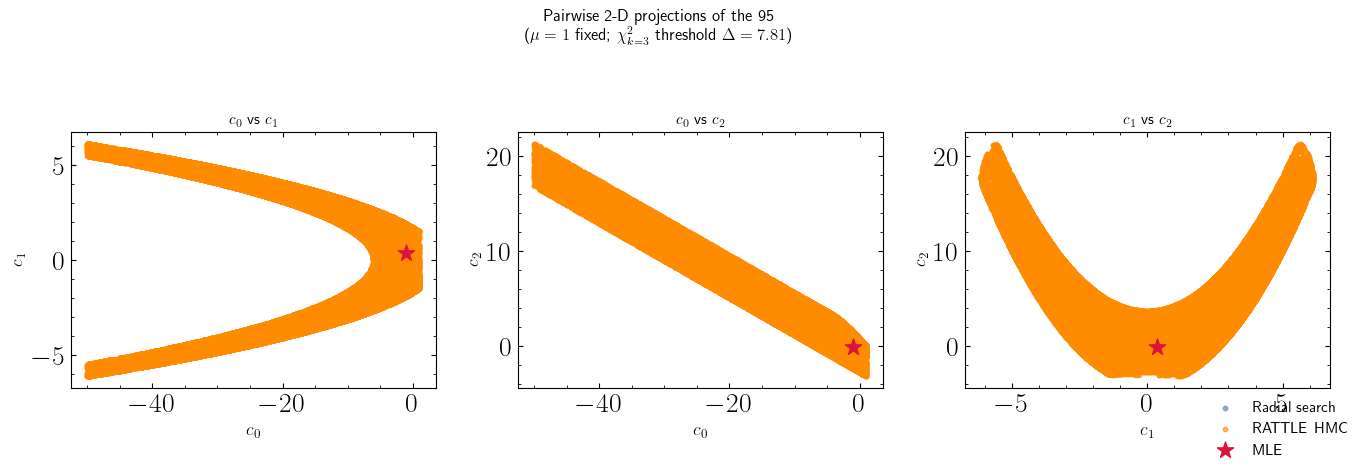

In [ ]:
pts = result.contour_points  # shape (N, 3)
radial_mask = result.from_radial  # bool
mle = result.theta_mle  # (c0_hat, c1_hat, c2_hat)
latex_names = [r"$c_0$", r"$c_1$", r"$c_2$"]

pairs = list(combinations(range(k), 2))  # 3 pairs for k=3

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(
    "Pairwise 2-D projections of the 95% CL confidence contour\n"
    rf"($\mu=1$ fixed; $\chi^2_{{k=3}}$ threshold $\Delta = {result.delta:.2f}$)",
    fontsize=12,
    y=1.02,
)

for ax, (i, j) in zip(axes, pairs):
    ax.scatter(
        pts[radial_mask, i],
        pts[radial_mask, j],
        s=10,
        alpha=0.6,
        color="steelblue",
        label="Radial search",
    )
    ax.scatter(
        pts[~radial_mask, i],
        pts[~radial_mask, j],
        s=10,
        alpha=0.6,
        color="darkorange",
        label="RATTLE HMC",
    )
    ax.scatter(mle[i], mle[j], s=150, color="crimson", marker="*", zorder=5, label="MLE")
    ax.set_xlabel(latex_names[i], fontsize=13)
    ax.set_ylabel(latex_names[j], fontsize=13)
    ax.set_title(f"{latex_names[i]} vs {latex_names[j]}", fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

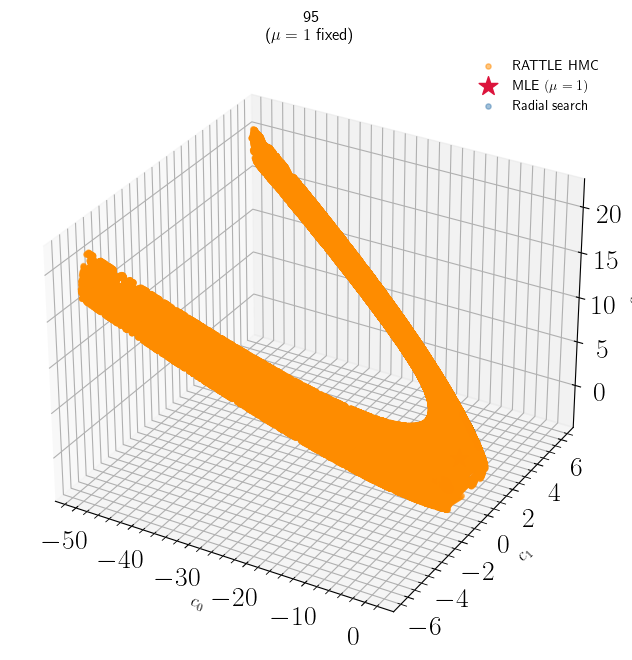

In [ ]:
# ── 3-D scatter of the contour surface ───────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(9, 7))
ax3 = fig.add_subplot(111, projection="3d")

ax3.scatter(
    pts[~radial_mask, 0],
    pts[~radial_mask, 1],
    pts[~radial_mask, 2],
    s=14,
    alpha=0.5,
    color="darkorange",
    label="RATTLE HMC",
)
ax3.scatter(
    mle[0],
    mle[1],
    mle[2],
    s=200,
    color="crimson",
    marker="*",
    zorder=6,
    label="MLE $(\\mu=1)$",
)
ax3.scatter(
    pts[radial_mask, 0],
    pts[radial_mask, 1],
    pts[radial_mask, 2],
    s=14,
    alpha=0.5,
    color="steelblue",
    label="Radial search",
    zorder=100,
)

ax3.set_xlabel(r"$c_0$", fontsize=12)
ax3.set_ylabel(r"$c_1$", fontsize=12)
ax3.set_zlabel(r"$c_2$", fontsize=12)
ax3.set_title(
    r"95% CL contour surface in $(c_0, c_1, c_2)$ signal-parameter space"
    "\n" + r"($\mu=1$ fixed)",
    fontsize=12,
)
ax3.legend(fontsize=10)
plt.tight_layout()
plt.show()

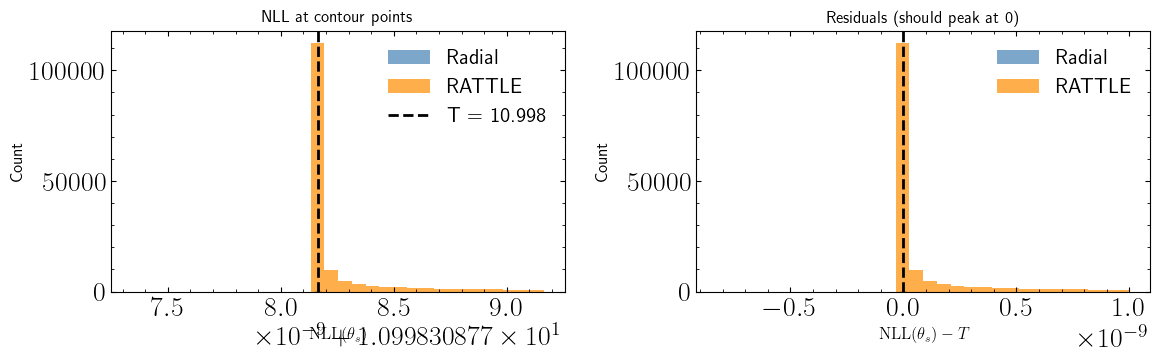

Max  |residual| : 1.00e-09
Mean |residual| : 7.31e-11


In [ ]:
# ── NLL residuals at all contour points ──────────────────────────────────────
nll_vals_all = np.array([nll_fixed(pts[i]) for i in range(len(pts))])
residuals_all = nll_vals_all - result.threshold

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    nll_vals_all[radial_mask], bins=30, alpha=0.7, color="steelblue", label="Radial"
)
axes[0].hist(
    nll_vals_all[~radial_mask], bins=30, alpha=0.7, color="darkorange", label="RATTLE"
)
axes[0].axvline(
    result.threshold, color="k", ls="--", lw=2, label=f"T = {result.threshold:.3f}"
)
axes[0].set_xlabel(r"$\mathrm{NLL}(\theta_s)$", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("NLL at contour points", fontsize=12)
axes[0].legend()

axes[1].hist(
    residuals_all[radial_mask], bins=30, alpha=0.7, color="steelblue", label="Radial"
)
axes[1].hist(
    residuals_all[~radial_mask], bins=30, alpha=0.7, color="darkorange", label="RATTLE"
)
axes[1].axvline(0, color="k", ls="--", lw=2)
axes[1].set_xlabel(r"$\mathrm{NLL}(\theta_s) - T$", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Residuals (should peak at 0)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Max  |residual| : {np.abs(residuals_all).max():.2e}")
print(f"Mean |residual| : {np.abs(residuals_all).mean():.2e}")

(algo)=
## 7 · Algorithm Walk-through

This section steps through each internal stage manually.

### Stage 1 — Pre-whitening in signal-parameter space

`find_contour` evaluates the full $4\times4$ Hessian of $\log\mathcal{L}$ at $(\mu=1,\,\hat\theta_s)$, then extracts the $3\times3$ **signal-parameter block**:

$$
G = -\bigl[\nabla^2\log\mathcal{L}\bigr]_{\text{signal indices}}
\bigg|_{(\mu=1,\,\hat\theta_s)}.
$$

After Cholesky factorisation $G = LL^T$, the whitened coordinate $\varphi = L(\theta_s - \hat\theta_s)$ makes the contour approximately spherical in the 3-D signal space.


In [ ]:
# ── Full Hessian at (mu=1, theta_mle_signal) ─────────────────────────────────
hessian_fn = stat_model.backend.get_hessian_logpdf_func()
theta_mle_full = np.concatenate([[1.0], mle])  # [mu=1, c0_hat, c1_hat, c2_hat]

H_full = np.array(hessian_fn(theta_mle_full), dtype=float)  # 4×4
print("Full 4×4 Hessian of logpdf at (mu=1, θ̂s):")
print(np.round(H_full, 4))
print()

# ── Extract the 3×3 signal-parameter block ───────────────────────────────────
ix = np.ix_(signal_indices, signal_indices)
H_signal = H_full[ix]  # 3×3 block
G_signal = -H_signal  # Fisher information for signal params

print("3×3 signal-parameter block G = -H_signal:")
print(np.round(G_signal, 4))
print()

eigvals = np.linalg.eigvalsh(G_signal)
print(f"Eigenvalues of G: {eigvals.round(4)}")
print("(Large spread → strongly anisotropic → whitening is important)")

Full 4×4 Hessian of logpdf at (mu=1, θ̂s):
[[-2.0413  1.8607  0.9961  2.3241]
 [ 1.8607 -1.7084 -0.9474 -2.0542]
 [ 0.9961 -0.9474 -0.6137 -0.9256]
 [ 2.3241 -2.0542 -0.9256 -2.9886]]

3×3 signal-parameter block G = -H_signal:
[[1.7084 0.9474 2.0542]
 [0.9474 0.6137 0.9256]
 [2.0542 0.9256 2.9886]]

Eigenvalues of G: [2.0000e-04 4.1090e-01 4.8997e+00]
(Large spread → strongly anisotropic → whitening is important)


In [ ]:
# ── Cholesky factorisation ─────────────────────────────────────────────────────
reg = 1e-8
w, V = np.linalg.eigh(G_signal)
w_reg = np.maximum(w, reg)
G_reg = (V * w_reg) @ V.T
L = np.linalg.cholesky(G_reg)

print("Cholesky factor L  (3×3):")
print(np.round(L, 4))
print()
print(f"Approx. whitened-space contour radius √Δ = {np.sqrt(delta):.4f}")
print("Radial search starts with this as the initial bracket radius.")

Cholesky factor L  (3×3):
[[ 1.3071  0.      0.    ]
 [ 0.7248  0.2972  0.    ]
 [ 1.5716 -0.7185  0.0478]]

Approx. whitened-space contour radius √Δ = 2.7955
Radial search starts with this as the initial bracket radius.


### Stage 2 — Radial Search

For each random unit vector $\hat{e}$ on $S^2$, the algorithm solves

$$
f(r) = \mathrm{NLL}\!\bigl(\hat\theta_s + L^{-T}(r\hat{e})\bigr) - T = 0
$$

via Brent's method.  Note that the NLL here is always evaluated with $\mu=1$:

$$
\mathrm{NLL}(\theta_s)
= -\log\mathcal{L}\bigl(\mu{=}1,\,\theta_s\bigr).
$$


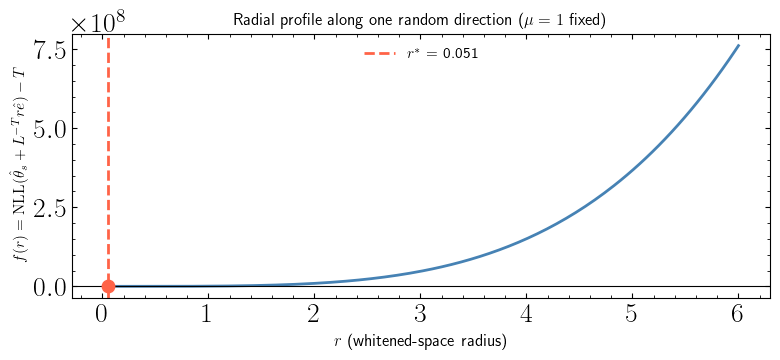

Root r*      = 0.0507
NLL(θ*)      = 10.998309
Threshold T  = 10.998309
Residual     = 9.91e-13


In [ ]:
from scipy.optimize import root_scalar

L_inv_T = np.linalg.solve(L, np.eye(k)).T  # L^{-T}

rng_demo = np.random.default_rng(7)
z = rng_demo.standard_normal(k)
e = z / np.linalg.norm(z)  # random unit vector on S²


def f(r):
    theta_s = mle + L_inv_T @ (r * e)
    return nll_fixed(theta_s) - result.threshold


r_vals = np.linspace(0.01, 6.0, 200)
f_vals = np.array([f(r) for r in r_vals])

r_hi = np.sqrt(delta)
while f(r_hi) <= 0 and r_hi < 30:
    r_hi *= 2
sol = root_scalar(f, bracket=[1e-8, r_hi], method="brentq", xtol=1e-12)
r_star = sol.root
theta_star = mle + L_inv_T @ (r_star * e)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_vals, f_vals, color="steelblue", lw=2)
ax.axhline(0, color="k", lw=0.8)
ax.axvline(r_star, color="tomato", ls="--", lw=2, label=rf"$r^*$ = {r_star:.3f}")
ax.scatter([r_star], [0], color="tomato", s=80, zorder=5)
ax.set_xlabel(r"$r$  (whitened-space radius)", fontsize=12)
ax.set_ylabel(r"$f(r) = \mathrm{NLL}(\hat\theta_s + L^{-T}r\hat{e}) - T$", fontsize=11)
ax.set_title(r"Radial profile along one random direction ($\mu=1$ fixed)", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Root r*      = {r_star:.4f}")
print(f"NLL(θ*)      = {nll_fixed(theta_star):.6f}")
print(f"Threshold T  = {result.threshold:.6f}")
print(f"Residual     = {abs(nll_fixed(theta_star) - result.threshold):.2e}")

### Stage 3 — Gap Detection

After the radial search, $M \gg N$ candidate unit vectors $c$ on $S^2$ are sampled and scored by their maximum cosine similarity to the already-found directions:

$$
s(c) = \max_{d\in\mathcal{D}} \langle c, d \rangle.
$$

The $n_{\rm chains}$ candidates with the smallest $s$ (largest angular gap) seed the RATTLE chains.


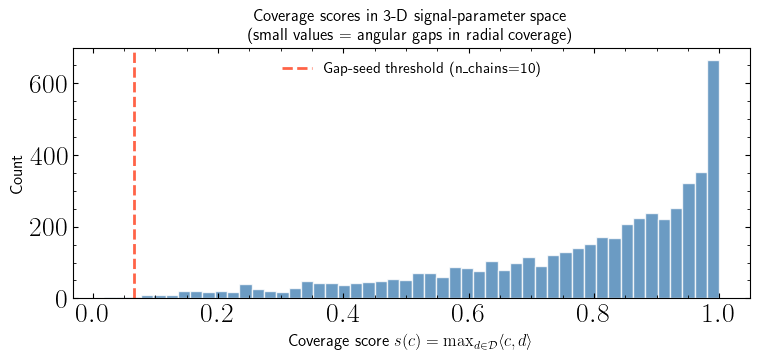

In [ ]:
# ── Coverage scores over a large candidate set ───────────────────────────────
radial_pts = result.contour_points[result.from_radial]  # radial contour points

# Whitened directions corresponding to the radial contour points
phi_radial = (radial_pts - mle) @ L.T
dirs_radial = phi_radial / np.linalg.norm(phi_radial, axis=1, keepdims=True)

rng_gap = np.random.default_rng(99)
M = 5000
Z = rng_gap.standard_normal((M, k))
cands = Z / np.linalg.norm(Z, axis=1, keepdims=True)
cos_sim = cands @ dirs_radial.T
coverage = np.max(cos_sim, axis=1)

n_chains = 10
gap_threshold = np.sort(coverage)[n_chains]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(coverage, bins=50, color="steelblue", alpha=0.8, edgecolor="white")
ax.axvline(
    gap_threshold,
    color="tomato",
    ls="--",
    lw=2,
    label=f"Gap-seed threshold (n_chains={n_chains})",
)
ax.set_xlabel(
    r"Coverage score $s(c) = \max_{d\in\mathcal{D}}\langle c,d\rangle$", fontsize=12
)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    "Coverage scores in 3-D signal-parameter space\n"
    "(small values = angular gaps in radial coverage)",
    fontsize=12,
)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Stage 4 — Constrained RATTLE HMC

The RATTLE algorithm walks along the constraint surface $C(\theta_s) = \mathrm{NLL}(\theta_s) - T = 0$ using gradient information.  The NLL gradient is computed by **autograd**, which differentiates through the `anp.concatenate([..., [1.0], ...])` insertion used to fix $\mu=1$:

$$
\nabla_{\theta_s}\mathrm{NLL}(\theta_s)
= \frac{\partial}{\partial\theta_s}
  \bigl[-\log\mathcal{L}(\mu{=}1,\theta_s)\bigr].
$$

One RATTLE leapfrog step (step size $\varepsilon$):

$$
p_{1/2} = p_0 - \tfrac{\varepsilon}{2}\nabla\mathrm{NLL}(\theta_0),
\quad
\theta' = \theta_0 + \varepsilon\,p_{1/2},
$$
$$
\theta_1 = \theta' - \frac{\mathrm{NLL}(\theta')-T}{|\nabla\mathrm{NLL}(\theta')|^2}
           \nabla\mathrm{NLL}(\theta'),
\quad
p_1 = \Bigl(p_{1/2} - \tfrac{\varepsilon}{2}\nabla\mathrm{NLL}(\theta_1)\Bigr)_{\perp \nabla\mathrm{NLL}(\theta_1)}.
$$


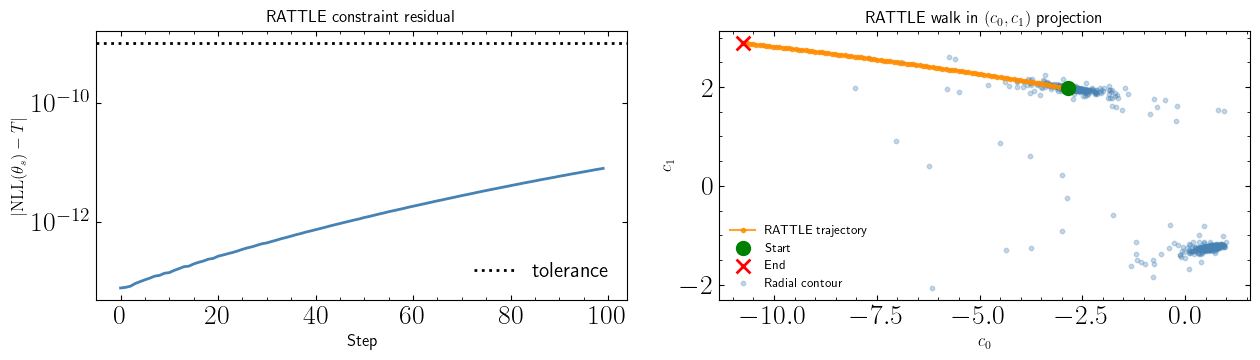

In [ ]:
import autograd
import autograd.numpy as anp

# ── Build autograd-differentiable NLL with mu=1 fixed ────────────────────────
logpdf_ag = stat_model.backend.get_logpdf_func()


def _nll_auto(signal_pars):
    """NLL(c0,c1,c2) with mu=1 inserted at poi_index=0; autograd-traced."""
    full_pars = anp.concatenate([anp.array([1.0]), signal_pars])
    return -logpdf_ag(full_pars)


_grad_auto = autograd.grad(_nll_auto)


def grad_nll(signal_pars):
    return np.array(_grad_auto(np.asarray(signal_pars, dtype=float)), dtype=float)


# ── Short RATTLE walk from a radial contour point ────────────────────────────
start = result.contour_points[0].copy()

# Project start onto constraint surface (handle tiny numerical drift)
theta_walk = start.copy()
for _ in range(50):
    res_val = nll_fixed(theta_walk) - result.threshold
    if abs(res_val) < 1e-9:
        break
    g = grad_nll(theta_walk)
    theta_walk -= (res_val / np.dot(g, g)) * g

# Initial tangent-space momentum
rng_walk = np.random.default_rng(1234)
g0 = grad_nll(theta_walk)
raw_p = rng_walk.standard_normal(k)
p_walk = raw_p - (np.dot(raw_p, g0) / np.dot(g0, g0)) * g0

eps = 0.05
trajectory = [theta_walk.copy()]
resid_track = []

for step in range(100):
    g = grad_nll(theta_walk)
    p_half = p_walk - (eps / 2) * g
    theta_prime = theta_walk + eps * p_half
    # SHAKE: Newton projection onto NLL = T
    for _ in range(100):
        rv = nll_fixed(theta_prime) - result.threshold
        if abs(rv) < 1e-9:
            break
        gp = grad_nll(theta_prime)
        theta_prime -= (rv / np.dot(gp, gp)) * gp
    g1 = grad_nll(theta_prime)
    p_prime = p_half - (eps / 2) * g1
    p_walk = p_prime - (np.dot(p_prime, g1) / np.dot(g1, g1)) * g1  # tangent proj.
    theta_walk = theta_prime
    trajectory.append(theta_walk.copy())
    resid_track.append(abs(nll_fixed(theta_walk) - result.threshold))

trajectory = np.array(trajectory)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogy(resid_track, color="steelblue", lw=2)
axes[0].axhline(1e-9, color="k", ls=":", label="tolerance")
axes[0].set_xlabel("Step", fontsize=12)
axes[0].set_ylabel(r"$|\mathrm{NLL}(\theta_s) - T|$", fontsize=12)
axes[0].set_title("RATTLE constraint residual", fontsize=12)
axes[0].legend()

axes[1].plot(
    trajectory[:, 0],
    trajectory[:, 1],
    "o-",
    color="darkorange",
    ms=3,
    lw=1.5,
    alpha=0.8,
    label="RATTLE trajectory",
)
axes[1].scatter(
    trajectory[0, 0], trajectory[0, 1], s=100, color="green", zorder=5, label="Start"
)
axes[1].scatter(
    trajectory[-1, 0],
    trajectory[-1, 1],
    s=100,
    color="red",
    marker="x",
    zorder=5,
    label="End",
)
axes[1].scatter(
    radial_pts[:, 0],
    radial_pts[:, 1],
    s=10,
    alpha=0.3,
    color="steelblue",
    label="Radial contour",
)
axes[1].set_xlabel(r"$c_0$", fontsize=12)
axes[1].set_ylabel(r"$c_1$", fontsize=12)
axes[1].set_title(r"RATTLE walk in $(c_0, c_1)$ projection", fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Summary

In this notebook we have:

1. **Built a statistical model** with four backend parameters $[\mu, c_0, c_1, c_2]$ using `MultivariateNormal` with `n_signal_parameters=3`.

2. **Fixed $\mu=1$** throughout the analysis.  `find_contour` uses `cfg.poi_index` to identify and exclude the signal strength from the contour search, then inserts $\mu=1$ at every NLL evaluation via `autograd.numpy.concatenate` — keeping the function autograd-differentiable.

3. **Found the MLE** $(\hat c_0, \hat c_1, \hat c_2)$ by passing `fixed_poi_value=1.0` to the spey optimizer, which holds $\mu$ fixed while minimising over the signal-shape parameters.

4. **Mapped the 95% CL contour** — the 2-D surface in the 3-D $(c_0, c_1, c_2)$ space where $\chi^2_{k=3}(\theta_s) = \Delta_{0.95} \approx 7.81$ — using:
   - **Radial search** in pre-whitened signal-parameter space, and
   - **Constrained RATTLE HMC** to fill angular gaps.

5. **Visualised** the result as pairwise 2-D projections and a 3-D scatter plot.

### Key design choices

| Choice | Reason |
|---|---|
| Fix $\mu=1$, not profile it | Contour represents physical signal-shape constraints |
| DoF = 3 (not 4) | Only signal-shape parameters enter Wilks' theorem |
| `anp.concatenate` for mu insertion | Keeps NLL autograd-differentiable for RATTLE |
| Signal block of Hessian for whitening | Correct Fisher information for the 3-D subspace |

### Further reading

- Wilks (1938), *Ann. Math. Stat.*
- Andersen (1983), *J. Comput. Phys.* — RATTLE algorithm
- `spey.multiparameter.contour` module — full mathematical derivation in module docstring
